In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import networkx as nx
from collections import Counter

import matplotlib.ticker as ticker
import numpy as np

from highlight_text import ax_text, fig_text

import os

hcol = '#ff4b44'
acol = '#00a0de'

# hcol = '#00a0de'
# acol = '#ff4b44'

In [9]:
df1 = pd.read_csv(r"D:\FData\Ligue_1_2024_25\ligue_1_2024_25.csv")

C:\Users\h\AppData\Local\Temp\ipykernel_9612\1845837462.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(r"D:\FData\Ligue_1_2024_25\ligue_1_2024_25.csv")


In [12]:
df1 = pd.read_csv(r"D:\FData\EPL_2023-24\EPL_2023_2024GW01_to_GW38.csv")

In [62]:
df2 = pd.read_csv(r"D:\FData\LaLiga_2024_25\laliga_till_gw38.csv")

In [13]:
df2 = pd.read_csv(r"D:\FData\LaLiga_2023-24\GW1_to_GW_38combinded.csv")

In [4]:
def xfig_calculator(df, team_name):
    teamdf = df[(df['teamName'] == team_name) | (df['oppositionTeamName'] == team_name)]
    mids = teamdf['matchId'].unique()

    partnership_list = []
    for mid in mids:
        match = teamdf[(teamdf['matchId'] == mid) & (teamdf['position'] == 'DC') & (teamdf['teamName'] == team_name)]
        cbs = tuple(sorted(match['shortName'].dropna().unique()))
        if len(cbs) >= 2:
            partnership_list.append(cbs)

    counter = Counter(partnership_list)
    data = [{'Partnership': p, 'Games': g} for p, g in counter.items()]
    team_data = pd.DataFrame(data).sort_values("Games", ascending=False).reset_index(drop=True)

    player_counter = Counter()
    for _, row in team_data.iterrows():
        for player in row['Partnership']:
            player_counter[player] += row['Games']

    player_df = pd.DataFrame.from_dict(player_counter, orient='index', columns=['Games Started'])
    player_df = player_df.sort_values('Games Started', ascending=False).reset_index().rename(columns={'index': 'Player'})

    xfig = len(team_data)
    yfig = len(player_df)

    return xfig, yfig

def cb_partnership_analysis(ax1, ax2, ax3, ax4, df, team_name):
    # --- Data Preparation (your existing logic is great) ---
    teamdf = df[(df['teamName'] == team_name) | (df['oppositionTeamName'] == team_name)]
    mids = teamdf['matchId'].unique()

    partnership_list = []
    for mid in mids:
        match = teamdf[(teamdf['matchId'] == mid) & (teamdf['position'] == 'DC') & (teamdf['teamName'] == team_name)]
        cbs = tuple(sorted(match['shortName'].dropna().unique()))
        if len(cbs) >= 2:
            partnership_list.append(cbs)

    counter = Counter(partnership_list)
    data = [{'Partnership': p, 'Games': g} for p, g in counter.items()]
    team_data = pd.DataFrame(data).sort_values("Games", ascending=False).reset_index(drop=True)
    # # Count how many CBs were used per partnership
    # team_data['CB_Count'] = team_data['Partnership'].apply(len)
    # # Group by CB count and sum total games
    # cb_usage = team_data.groupby('CB_Count')['Games'].sum()
    # # Total number of games considered
    # total_games = cb_usage.sum()
    # # Compute percentage
    # cb_usage_percentage = (cb_usage / total_games * 100).round(1)

    cb_usage = team_data.groupby(team_data['Partnership'].apply(len))['Games'].sum()
    total_starts = cb_usage.sum()
    dominant_cb = cb_usage.idxmax()
    dominant_starts = cb_usage[dominant_cb]
    dominant_pct = round((dominant_starts / total_starts) * 100)

    player_counter = Counter()
    for _, row in team_data.iterrows():
        for player in row['Partnership']:
            player_counter[player] += row['Games']

    player_df = pd.DataFrame.from_dict(player_counter, orient='index', columns=['Games Started'])
    player_df = player_df.sort_values('Games Started', ascending=False).reset_index().rename(columns={'index': 'Player'})
    
    # --- Plot 1: Partnership Bar Chart (Direct commands to ax1) ---
    bar_chart_data = team_data.sort_values("Games", ascending=False).reset_index(drop=True)
    partnership_labels = [' + '.join(p) for p in team_data['Partnership']]
    ax1.bar(partnership_labels, team_data['Games'], color=acol, edgecolor='black', width=0.5, zorder=2)
    ax1.set_ylabel("Games Started by Partnership", fontweight='bold', fontsize=15)
    ax1.set_xticklabels([]) # Hide x-axis labels as they are implicit
    ax1.tick_params(axis='x', length=0)
    # THIS IS THE NEW LINE TO REMOVE THE GAP
    ax1.set_xlim(left=-0.5, right=len(bar_chart_data)-0.5)
    # ax1.grid(True, zorder=0)
    ax1.spines['bottom'].set_visible(True) # Make it visible
    ax1.spines['bottom'].set_linewidth(1.5) # Then set its linewidth
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_visible(False)

    # 1. Ensure y-tick labels are integers and show only even numbers
    # Get the current y-limits to determine the range for ticks
    ymin, ymax = ax1.get_ylim()
    
    # Create a list of even integer ticks within your y-axis range
    # Make sure to adjust the range to cover your data's extent
    # A simple way to start from the first even number greater than or equal to ymin
    # and go up to the last even number less than or equal to ymax
    # You might need to adjust the start and end of this range based on your data.
    even_ticks = np.arange(np.ceil(ymin / 2) * 2, np.floor(ymax / 2) * 2 + 1, 2)
    
    ax1.set_yticks(even_ticks)
    
    # Optional: If you want to ensure the labels are formatted as integers
    # (though set_yticks with integer values often handles this automatically)
    formatter = ticker.FormatStrFormatter('%d')
    ax1.yaxis.set_major_formatter(formatter)
    
    
    # 2. Make y-grids appear only on even number lines
    # This is usually tied to your major ticks. If your major ticks are set to even numbers,
    # the grid lines for major ticks will naturally appear at those positions.
    ax1.grid(axis='y', which='major', alpha=0.7) # Grid for major ticks
    # You can optionally disable minor ticks and their grids if you don't want them
    ax1.yaxis.set_minor_locator(ticker.NullLocator()) # No minor ticks
    ax1.grid(axis='y', which='minor') # No minor grid lines

    # 2. Make x-grids appear only on even number lines
    # This is usually tied to your major ticks. If your major ticks are set to even numbers,
    # the grid lines for major ticks will naturally appear at those positions.
    ax1.grid(axis='x', which='major', alpha=0.7) # Grid for major ticks
    # You can optionally disable minor ticks and their grids if you don't want them
    ax1.yaxis.set_minor_locator(ticker.NullLocator()) # No minor ticks
    ax1.grid(axis='x', which='minor') # No minor grid lines


    # --- Plot 2: Partnership Timeline (Direct commands to ax2) ---
    player_order = player_df['Player'].unique()
    player_to_y = {player: i for i, player in enumerate(player_order)}
    
    plot_events = []
    current_game_slot = 0
    for _, row in team_data.iterrows():
        # This loop creates one plot event per PARTNERSHIP TYPE
        # The x-axis represents the partnership type index, not individual games.
        partnership = row['Partnership']
        plot_events.append({
            'x_pos': current_game_slot,
            'players': partnership
        })
        current_game_slot += 1
            
    total_slots = current_game_slot

    # Draw the gray background squares for the entire grid first
    x_grid = range(total_slots)
    for i in range(len(player_df)):
        y_grid = [i] * len(x_grid)
        ax2.plot(x_grid, y_grid,
                 marker='s',
                 markersize=12,
                 markerfacecolor='gray',
                 markeredgecolor='white',
                 linestyle='none',
                 zorder=1,
                 alpha=0.15) # Made slightly less transparent

    # Plot the vertical lines and colored markers for each game event
    for event in plot_events:
        x = event['x_pos']
        players_in_game = event['players']
        y_coords = [player_to_y[p] for p in players_in_game]
        
        if len(y_coords) > 1:
            ax2.vlines(x=x, ymin=min(y_coords), ymax=max(y_coords), color=hcol, lw=2, zorder=2)
        
        ax2.plot([x]*len(y_coords), y_coords,
                 marker='s',
                 markersize=13,
                 markerfacecolor=hcol,
                 markeredgecolor='black',
                 linestyle='none',
                 zorder=3)

    # --- Styling for Plot 2 ---
    # Add alternating gray background bands for each player row
    for i in range(len(player_order)):
        if i % 2 == 1:
            ax2.axhspan(i - 0.5, i + 0.5, color='#f0f0f0', zorder=0)
    ax2.set_yticks(range(len(player_order)))
    ax2.set_yticklabels(player_order)
    ax2.tick_params(axis='y', length=0)
    ax2.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax2.invert_yaxis()
    ax2.set_xlim(-0.5, total_slots - 0.5)
    for spine in ax2.spines.values():
        spine.set_visible(False)


    # --- Plot 3: player bar chart ---
    ax3.barh(player_df['Player'], player_df['Games Started'], color=acol, edgecolor='black', 
             height=0.5, 
             zorder=2
             )
    for i in range(len(player_order)):
        if i % 2 == 1:
            ax3.axhspan(i - 0.5, i + 0.5, color='#f0f0f0', zorder=0)
    ax3.invert_xaxis()
    ax3.invert_yaxis()
    ax3.spines['right'].set_visible(True) # Make it visible
    ax3.spines['right'].set_linewidth(1.5) # Then set its linewidth
    ax3.spines['top'].set_visible(False)
    ax3.spines['bottom'].set_visible(False)
    ax3.spines['left'].set_visible(False)
    ax3.tick_params(axis='y', which='both', right=False, left=False, labelbottom=False)
    ax3.set_yticklabels([])
    ax3.set_title('Games Started by Players', fontweight='bold', y=-0.25, va='top')
    formatter = ticker.FormatStrFormatter('%d')
    ax3.xaxis.set_major_formatter(formatter)


    # --- Plot 4: Stats Texts ---
    # Assuming team_data might be empty, add a check
    if not team_data.empty:
        most_common_partnership = ' + '.join(team_data['Partnership'][0])
        mcp_num = team_data['Games'][0]
        mcp_pct = round((mcp_num/38)*100)
        ax4.text(0.5, 0.8, f"Most Common Partnership:", fontweight='bold', fontsize=15, ha='center', va='center')
        ax4.text(0.5, 0.75, f"{most_common_partnership}", color=hcol, fontsize=15, ha='center', va='center')
        ax4.text(0.5, 0.7, f"{mcp_num} starts ({mcp_pct}%)", color=acol, fontsize=15, ha='center', va='center')
        
        ax4.text(0.5, 0.55, "Mostly 2 or 3CBs?", fontsize=15, fontweight='bold', ha='center', va='center')
        ax4.text(0.5, 0.5, f"{dominant_cb} CBs", color=hcol, fontsize=15, ha='center', va='center')
        ax4.text(0.5, 0.45, f"{dominant_starts} starts ({dominant_pct}%)", color=acol, fontsize=15, ha='center', va='center')

        ax4.text(0.5, 0.3, "Different Partnerships:", fontsize=15, fontweight='bold', ha='center', va='center')
        ax4.text(0.5, 0.25, f"{len(team_data)}", color=hcol, fontsize=15, ha='center', va='center')
    else:
        ax4.text(0.5, 0.5, "No partnerships found.", ha='center', va='center')
    for spine in ax4.spines.values():
        spine.set_visible(False)

    ax4.tick_params(axis='y', which='both', right=False, left=False, labelbottom=False)
    ax4.tick_params(axis='x', which='both', top=False, bottom=False, labelbottom=False)
    ax4.set_xticklabels([])
    ax4.set_yticklabels([])

    return 

# # --- Main Plotting Logic ---
# team_name = 'Man Utd'
# xfig, yfig = xfig_calculator(df1, team_name)
# fixed_column_width = 5
# fixed_column_height = 6
# dynamic_column_width = xfig/2
# dynamic_column_height = yfig/2

# # Create a figure
# fig = plt.figure(figsize=(fixed_column_width + dynamic_column_width, fixed_column_height + dynamic_column_height))

# # Define the GridSpec layout
# gs = fig.add_gridspec(nrows=2, ncols=3, width_ratios=[fixed_column_width, dynamic_column_width/2, dynamic_column_width/2],
#                                         height_ratios=[fixed_column_height, dynamic_column_height])

# # Assign subplots to specific grid cells
# ax4 = fig.add_subplot(gs[0, 0]) # Top-left (Stats Texts)
# ax1 = fig.add_subplot(gs[0, 1:]) # Top-right merged (Partnership Bar Chart)
# ax3 = fig.add_subplot(gs[1, 0]) # Bottom-left (Player Bar Chart)
# ax2 = fig.add_subplot(gs[1, 1:]) # Bottom-right merged (Partnership Timeline)


# # Call your analysis function with the new axes
# cb_partnership_analysis(ax1, ax2, ax3, ax4, df1, team_name)

# # Add an overall title to the figure
# fig.text(0.5, 1, f'{team_name} Center-Back Partnership Analysis', fontsize=20, fontweight='bold', ha='center')
# fig.text(0.5, 0.97, 'in EPL 2024-25 season | Data: Opta | made by: @adnaaan433', fontsize=15, ha='center')

# # Use tight_layout to prevent plots and labels from overlapping
# plt.tight_layout(rect=[0, 0, 1, 0.93])
# plt.show()

In [10]:
sorted(df1.teamName.unique())

['Angers',
 'Auxerre',
 'Brest',
 'Le Havre',
 'Lens',
 'Lille',
 'Lyon',
 'Marseille',
 'Monaco',
 'Montpellier',
 'Nantes',
 'Nice',
 'PSG',
 'Reims',
 'Rennes',
 'Saint-Etienne',
 'Strasbourg',
 'Toulouse']

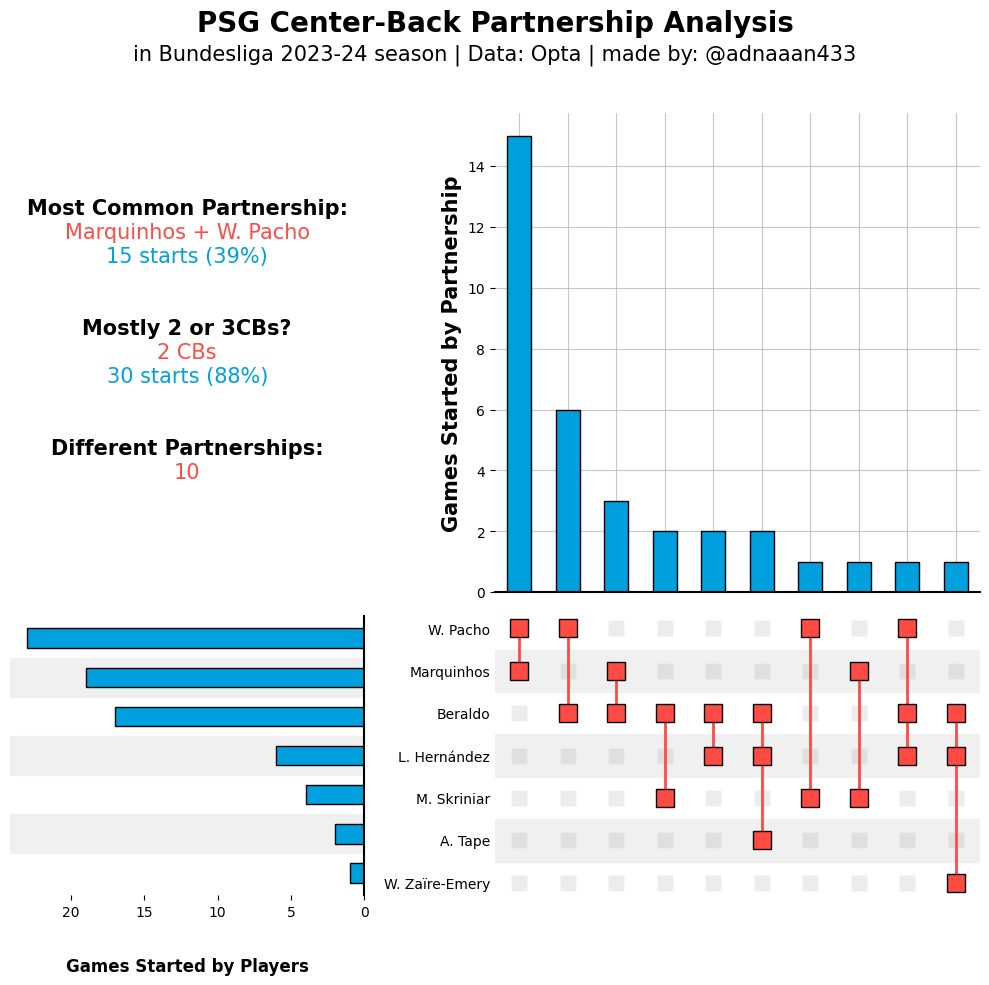

In [11]:
# --- Main Plotting Logic ---
team_name = 'PSG'
xfig, yfig = xfig_calculator(df1, team_name)
fixed_column_width = 5
fixed_column_height = 6
dynamic_column_width = xfig/2
dynamic_column_height = yfig/2

# Create a figure
fig = plt.figure(figsize=(fixed_column_width + dynamic_column_width, fixed_column_height + dynamic_column_height))

# Define the GridSpec layout
gs = fig.add_gridspec(nrows=2, ncols=3, width_ratios=[fixed_column_width, dynamic_column_width/2, dynamic_column_width/2],
                                        height_ratios=[fixed_column_height, dynamic_column_height])

# Assign subplots to specific grid cells
ax4 = fig.add_subplot(gs[0, 0]) # Top-left (Stats Texts)
ax1 = fig.add_subplot(gs[0, 1:]) # Top-right merged (Partnership Bar Chart)
ax3 = fig.add_subplot(gs[1, 0]) # Bottom-left (Player Bar Chart)
ax2 = fig.add_subplot(gs[1, 1:]) # Bottom-right merged (Partnership Timeline)


# Call your analysis function with the new axes
cb_partnership_analysis(ax1, ax2, ax3, ax4, df1, team_name)

# Add an overall title to the figure
fig.text(0.5, 1, f'{team_name} Center-Back Partnership Analysis', fontsize=20, fontweight='bold', ha='center')
fig.text(0.5, 0.97, 'in Bundesliga 2023-24 season | Data: Opta | made by: @adnaaan433', fontsize=15, ha='center')

# Use tight_layout to prevent plots and labels from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()

In [12]:
# Ensure the output directory exists
output_dir = r"D:\FData\Ligue_1_2024_25\Analysis\CB_Partnership"
os.makedirs(output_dir, exist_ok=True)

# List of team names
team_names = df1['teamName'].unique()  # Or your custom list like ['Arsenal', 'Man City', ...]

for team_name in team_names:
    # --- Main Plotting Logic ---
    xfig, yfig = xfig_calculator(df1, team_name)
    fixed_column_width = 5
    fixed_column_height = 6
    dynamic_column_width = xfig / 2
    dynamic_column_height = yfig / 2

    # Create a figure
    fig = plt.figure(figsize=(fixed_column_width + dynamic_column_width, 
                              fixed_column_height + dynamic_column_height))

    # Define the GridSpec layout
    gs = fig.add_gridspec(nrows=2, ncols=3, 
                          width_ratios=[fixed_column_width, dynamic_column_width / 2, dynamic_column_width / 2],
                          height_ratios=[fixed_column_height, dynamic_column_height])

    # Assign subplots to specific grid cells
    ax4 = fig.add_subplot(gs[0, 0])       # Top-left (Stats Texts)
    ax1 = fig.add_subplot(gs[0, 1:])      # Top-right merged (Partnership Bar Chart)
    ax3 = fig.add_subplot(gs[1, 0])       # Bottom-left (Player Bar Chart)
    ax2 = fig.add_subplot(gs[1, 1:])      # Bottom-right merged (Partnership Timeline)

    # Call your analysis function
    cb_partnership_analysis(ax1, ax2, ax3, ax4, df1, team_name)

    # Add overall title and attribution
    fig.text(0.5, 1, f'{team_name} Center-Back Partnership Analysis', fontsize=20, fontweight='bold', ha='center')
    fig.text(0.5, 0.97, 'in Bundesliga 2024-25 season | Data: Opta | made by: @adnaaan433', fontsize=15, ha='center')

    # Apply tight layout
    plt.tight_layout(rect=[0, 0, 1, 0.93])

    # Save the figure
    filename = f"{team_name.replace(' ', '_')}_cb_partnership.png"
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(f"Saved plot for {team_name} at {filepath}")

Saved plot for Le Havre at D:\FData\Ligue_1_2024_25\Analysis\CB_Partnership\Le_Havre_cb_partnership.png
Saved plot for PSG at D:\FData\Ligue_1_2024_25\Analysis\CB_Partnership\PSG_cb_partnership.png
Saved plot for Marseille at D:\FData\Ligue_1_2024_25\Analysis\CB_Partnership\Marseille_cb_partnership.png
Saved plot for Brest at D:\FData\Ligue_1_2024_25\Analysis\CB_Partnership\Brest_cb_partnership.png
Saved plot for Reims at D:\FData\Ligue_1_2024_25\Analysis\CB_Partnership\Reims_cb_partnership.png
Saved plot for Lille at D:\FData\Ligue_1_2024_25\Analysis\CB_Partnership\Lille_cb_partnership.png
Saved plot for Saint-Etienne at D:\FData\Ligue_1_2024_25\Analysis\CB_Partnership\Saint-Etienne_cb_partnership.png
Saved plot for Monaco at D:\FData\Ligue_1_2024_25\Analysis\CB_Partnership\Monaco_cb_partnership.png
Saved plot for Montpellier at D:\FData\Ligue_1_2024_25\Analysis\CB_Partnership\Montpellier_cb_partnership.png
Saved plot for Strasbourg at D:\FData\Ligue_1_2024_25\Analysis\CB_Partnership\

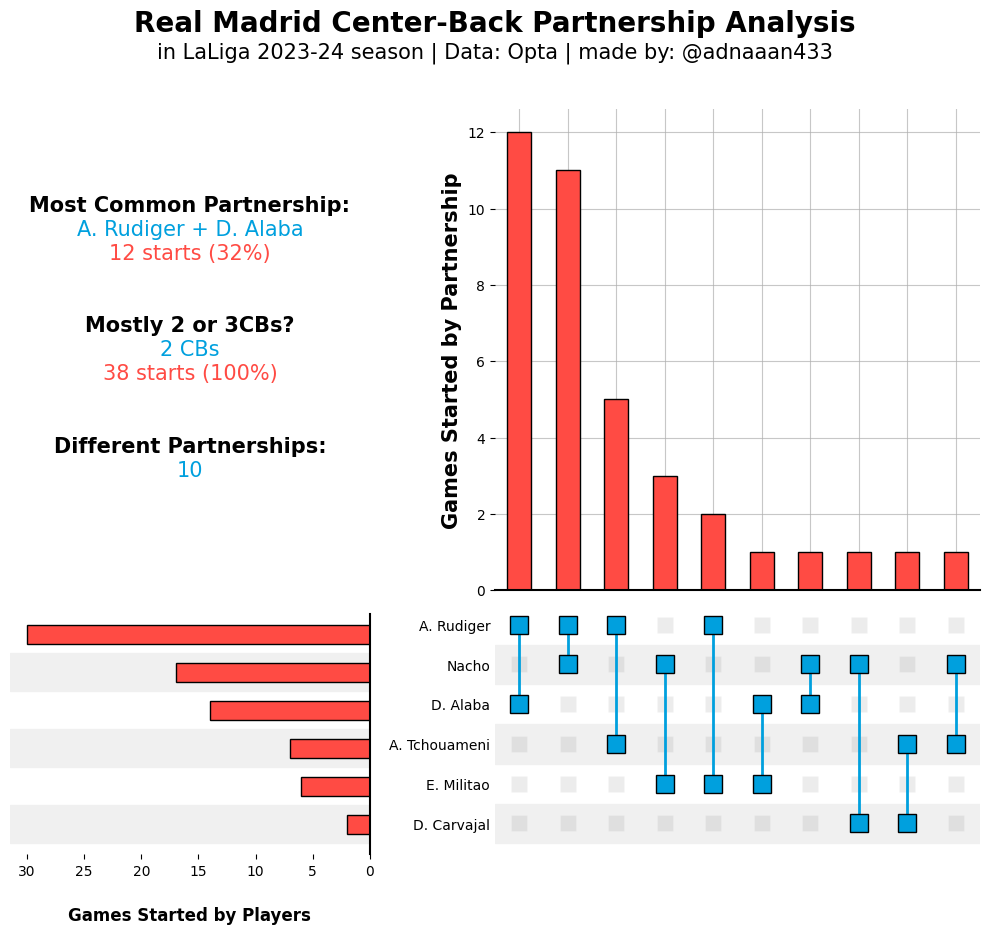

In [19]:
# --- Main Plotting Logic ---
team_name = 'Real Madrid'
xfig, yfig = xfig_calculator(df2, team_name)
fixed_column_width = 5
fixed_column_height = 6
dynamic_column_width = xfig/2
dynamic_column_height = yfig/2

# Create a figure
fig = plt.figure(figsize=(fixed_column_width + dynamic_column_width, fixed_column_height + dynamic_column_height))

# Define the GridSpec layout
gs = fig.add_gridspec(nrows=2, ncols=3, width_ratios=[fixed_column_width, dynamic_column_width/2, dynamic_column_width/2],
                                        height_ratios=[fixed_column_height, dynamic_column_height])

# Assign subplots to specific grid cells
ax4 = fig.add_subplot(gs[0, 0]) # Top-left (Stats Texts)
ax1 = fig.add_subplot(gs[0, 1:]) # Top-right merged (Partnership Bar Chart)
ax3 = fig.add_subplot(gs[1, 0]) # Bottom-left (Player Bar Chart)
ax2 = fig.add_subplot(gs[1, 1:]) # Bottom-right merged (Partnership Timeline)


# Call your analysis function with the new axes
cb_partnership_analysis(ax1, ax2, ax3, ax4, df2, team_name)

# Add an overall title to the figure
fig.text(0.5, 1, f'{team_name} Center-Back Partnership Analysis', fontsize=20, fontweight='bold', ha='center')
fig.text(0.5, 0.97, 'in LaLiga 2023-24 season | Data: Opta | made by: @adnaaan433', fontsize=15, ha='center')

# Use tight_layout to prevent plots and labels from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [20]:
# Ensure the output directory exists
output_dir = r"D:\FData\LaLiga_2023-24\Analysis\CB_Partnership"
os.makedirs(output_dir, exist_ok=True)

# List of team names
team_names = df2['teamName'].unique()  # Or your custom list like ['Arsenal', 'Man City', ...]

for team_name in team_names:
    # --- Main Plotting Logic ---
    xfig, yfig = xfig_calculator(df2, team_name)
    fixed_column_width = 5
    fixed_column_height = 6
    dynamic_column_width = xfig / 2
    dynamic_column_height = yfig / 2

    # Create a figure
    fig = plt.figure(figsize=(fixed_column_width + dynamic_column_width, 
                              fixed_column_height + dynamic_column_height))

    # Define the GridSpec layout
    gs = fig.add_gridspec(nrows=2, ncols=3, 
                          width_ratios=[fixed_column_width, dynamic_column_width / 2, dynamic_column_width / 2],
                          height_ratios=[fixed_column_height, dynamic_column_height])

    # Assign subplots to specific grid cells
    ax4 = fig.add_subplot(gs[0, 0])       # Top-left (Stats Texts)
    ax1 = fig.add_subplot(gs[0, 1:])      # Top-right merged (Partnership Bar Chart)
    ax3 = fig.add_subplot(gs[1, 0])       # Bottom-left (Player Bar Chart)
    ax2 = fig.add_subplot(gs[1, 1:])      # Bottom-right merged (Partnership Timeline)

    # Call your analysis function
    cb_partnership_analysis(ax1, ax2, ax3, ax4, df2, team_name)

    # Add overall title and attribution
    fig.text(0.5, 1, f'{team_name} Center-Back Partnership Analysis', fontsize=20, fontweight='bold', ha='center')
    fig.text(0.5, 0.97, 'in LaLiga 2023-24 season | Data: Opta | made by: @adnaaan433', fontsize=15, ha='center')

    # Apply tight layout
    plt.tight_layout(rect=[0, 0, 1, 0.93])

    # Save the figure
    filename = f"{team_name.replace(' ', '_')}_cb_partnership.png"
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(f"Saved plot for {team_name} at {filepath}")

Saved plot for Almeria at D:\FData\LaLiga_2023-24\Analysis\CB_Partnership\Almeria_cb_partnership.png
Saved plot for Rayo Vallecano at D:\FData\LaLiga_2023-24\Analysis\CB_Partnership\Rayo_Vallecano_cb_partnership.png
Saved plot for Athletic Club at D:\FData\LaLiga_2023-24\Analysis\CB_Partnership\Athletic_Club_cb_partnership.png
Saved plot for Real Madrid at D:\FData\LaLiga_2023-24\Analysis\CB_Partnership\Real_Madrid_cb_partnership.png
Saved plot for Granada at D:\FData\LaLiga_2023-24\Analysis\CB_Partnership\Granada_cb_partnership.png
Saved plot for Atletico at D:\FData\LaLiga_2023-24\Analysis\CB_Partnership\Atletico_cb_partnership.png
Saved plot for Deportivo Alaves at D:\FData\LaLiga_2023-24\Analysis\CB_Partnership\Deportivo_Alaves_cb_partnership.png
Saved plot for Cadiz at D:\FData\LaLiga_2023-24\Analysis\CB_Partnership\Cadiz_cb_partnership.png
Saved plot for Osasuna at D:\FData\LaLiga_2023-24\Analysis\CB_Partnership\Osasuna_cb_partnership.png
Saved plot for Celta Vigo at D:\FData\LaL